# World Happiness Report — Predictions
Requires `happiness_clean.csv` from `main_analysis.ipynb`.

Covers:
1. Feature engineering
2. Linear regression baseline
3. Random Forest regressor
4. 2026 score forecast
5. Model evaluation

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import cross_val_score, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
df = pd.read_csv('happiness_clean.csv')
print(df.shape)

(2116, 22)


## 1  Feature engineering

In [10]:
breakdown_cols = [
    'explained_log_gdp_per_capita', 'explained_social_support',
    'explained_healthy_life_expectancy', 'explained_freedom',
    'explained_generosity', 'explained_corruption'
]

# Sort by year globally so TimeSeriesSplit folds respect time ordering across countries
df_sorted = df.sort_values('year').copy()

df_sorted['score_lag1']   = df_sorted.groupby('country')['happiness_score'].shift(1)
df_sorted['score_lag2']   = df_sorted.groupby('country')['happiness_score'].shift(2)
df_sorted['score_rolling3'] = (df_sorted.groupby('country')['happiness_score']
                                .transform(lambda x: x.shift(1).rolling(3, min_periods=2).mean()))

df_a = df_sorted.dropna(subset=['score_lag1']).copy()
print(f'Dataset A (lag features): {df_a.shape}')

# --- Dataset B: 2019+ with breakdown columns + lag ---
df_b_candidate = df_sorted[df_sorted['has_breakdown']].copy()
before = len(df_b_candidate)
df_b = df_b_candidate.dropna(subset=['score_lag1'] + breakdown_cols).copy()
print(f'Dropped {before - len(df_b)} rows due to missing lag/breakdown values')
print(f'Dataset B (breakdown features): {df_b.shape}')

Dataset A (lag features): (1948, 25)
Dropped 2 rows due to missing lag/breakdown values
Dataset B (breakdown features): (1011, 25)


## 2  Baseline — linear regression on lag features (Dataset A)

In [11]:
FEAT_A = ['score_lag1', 'score_lag2', 'score_rolling3', 'rank_in_year']
X_a = df_a[FEAT_A].fillna(df_a[FEAT_A].mean())
y_a = df_a['happiness_score']

tscv = TimeSeriesSplit(n_splits=5)
lr = LinearRegression()
scores_lr = cross_val_score(lr, X_a, y_a, cv=tscv, scoring='neg_mean_absolute_error')
print(f'Linear Regression  MAE: {-scores_lr.mean():.4f} (+/- {scores_lr.std():.4f})')

ridge = Ridge(alpha=1.0)
scores_ridge = cross_val_score(ridge, X_a, y_a, cv=tscv, scoring='neg_mean_absolute_error')
print(f'Ridge Regression   MAE: {-scores_ridge.mean():.4f} (+/- {scores_ridge.std():.4f})')

Linear Regression  MAE: 0.1172 (+/- 0.0160)
Ridge Regression   MAE: 0.1174 (+/- 0.0161)


## 3  Random Forest on breakdown features (Dataset B)

In [12]:
FEAT_B = breakdown_cols + ['score_lag1', 'score_rolling3']
X_b = df_b[FEAT_B].fillna(df_b[FEAT_B].mean())
y_b = df_b['happiness_score']

rf = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42)
scores_rf = cross_val_score(rf, X_b, y_b, cv=tscv, scoring='neg_mean_absolute_error')
print(f'Random Forest      MAE: {-scores_rf.mean():.4f} (+/- {scores_rf.std():.4f})')

gb = HistGradientBoostingRegressor(max_iter=200, max_depth=4, learning_rate=0.05, random_state=42)
scores_gb = cross_val_score(gb, X_b, y_b, cv=tscv, scoring='neg_mean_absolute_error')
print(f'Hist Grad Boosting MAE: {-scores_gb.mean():.4f} (+/- {scores_gb.std():.4f})')

Random Forest      MAE: 0.1422 (+/- 0.0188)
Hist Grad Boosting MAE: 0.1565 (+/- 0.0200)


## 4  Feature importance (Random Forest)

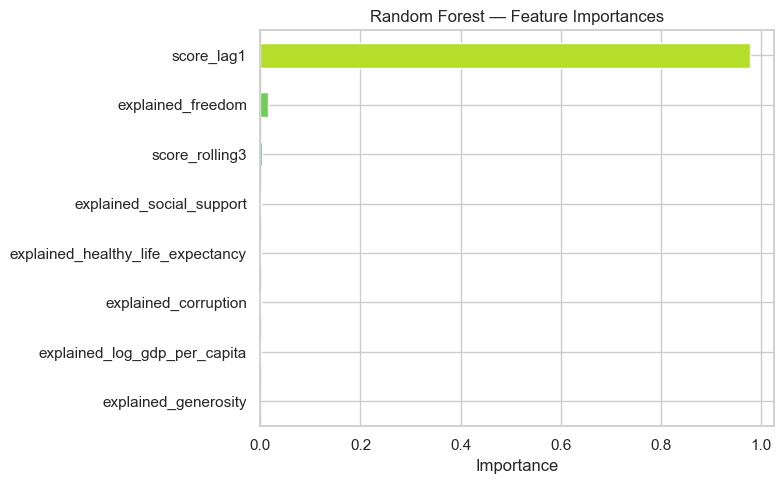

In [13]:
rf.fit(X_b, y_b)
importances = pd.Series(rf.feature_importances_, index=FEAT_B).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot.barh(ax=ax, color=sns.color_palette('viridis', len(importances)))
ax.set_title('Random Forest — Feature Importances')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('plot_feature_importance.png', dpi=150)
plt.show()

## 5  Forecast 2026 scores (all countries present in 2025)

In [14]:
# Fit best model on all available data then predict next year
rf_final = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42)
rf_final.fit(X_b, y_b)

# Build 2026 feature rows from 2025 data
df_2025 = df_b[df_b['year'] == 2025].copy()

# score_lag1 for 2026 = 2025 score; rolling3 = mean of 2023-2025
df_2025['score_lag1'] = df_2025['happiness_score']
df_2025['score_rolling3'] = df_2025['score_lag1']  # approximate

X_2026 = df_2025[FEAT_B]
df_2025['predicted_2026'] = rf_final.predict(X_2026)
df_2025['predicted_change'] = df_2025['predicted_2026'] - df_2025['happiness_score']

forecast = df_2025[['country','happiness_score','predicted_2026','predicted_change']].sort_values('predicted_2026', ascending=False)
forecast.columns = ['Country', '2025 Score', 'Predicted 2026', 'Change']
print('Top 10 predicted happiest in 2026:')
display(forecast.head(10))
print('Bottom 10 predicted:')
display(forecast.tail(10))

Top 10 predicted happiest in 2026:


,Country,2025 Score,Predicted 2026,Change
618,Finland,7.764,7.764866,0.000866
513,Denmark,7.539,7.538261,-0.000739
803,Iceland,7.540,7.531318,-0.008682
431,Costa Rica,7.439,7.410520,-0.028480
1809,Sweden,7.255,7.242620,-0.012380
1449,Norway,7.242,7.201695,-0.040305
1356,Netherlands,7.223,7.157367,-0.065633
887,Israel,7.187,7.151425,-0.035575
1119,Luxembourg,7.063,6.963229,-0.099771
1823,Switzerland,7.018,6.960649,-0.057351


Bottom 10 predicted:


,Country,2025 Score,Predicted 2026,Change
403,Comoros,3.925,3.951136,0.026136
590,Eswatini,3.909,3.950837,0.041837
499,DR Congo,3.761,3.919403,0.158403
1053,Lebanon,3.723,3.736464,0.013464
2087,Yemen,3.532,3.612765,0.080765
235,Botswana,3.464,3.490708,0.026708
2115,Zimbabwe,3.346,3.377712,0.031712
1147,Malawi,3.284,3.355955,0.071955
1668,Sierra Leone,3.251,3.291835,0.040835
13,Afghanistan,1.446,1.501222,0.055222


## 6  Predicted vs actual (in-sample on Dataset B)

In-sample  MAE=0.0989  R2=0.9853


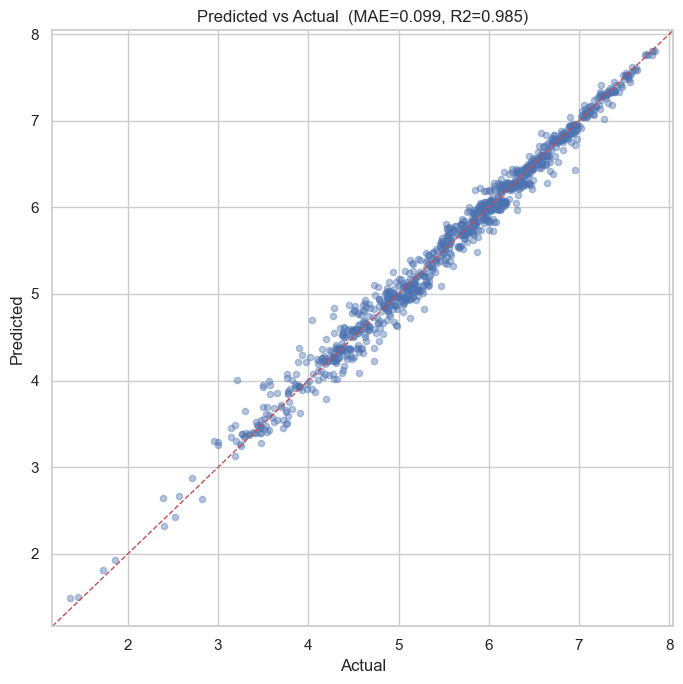

In [15]:
y_pred = rf_final.predict(X_b)
mae = mean_absolute_error(y_b, y_pred)
r2  = r2_score(y_b, y_pred)
print(f'In-sample  MAE={mae:.4f}  R2={r2:.4f}')

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_b, y_pred, alpha=0.4, s=20)
lims = [min(y_b.min(), y_pred.min()) - 0.2, max(y_b.max(), y_pred.max()) + 0.2]
ax.plot(lims, lims, 'r--', lw=1)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
ax.set_title(f'Predicted vs Actual  (MAE={mae:.3f}, R2={r2:.3f})')
plt.tight_layout()
plt.savefig('plot_pred_vs_actual.png', dpi=150)
plt.show()

## 7  Save forecast

In [16]:
forecast.to_csv('happiness_forecast_2026.csv', index=False)
print('Saved happiness_forecast_2026.csv')

Saved happiness_forecast_2026.csv
